# Smart Trash in Shadyside
---

## Introduction

Waste management is one of the most important investments a neighborhood can make when it comes to quality of life and economic success. No one wants to live, shop, or work in a dirty community, and Pittsburgh has been working for years to improve that. About a decade ago, they started introducing smart trash receptacles around the city that provide more accurate data on trash can usage. 

For more information, you can visit **https://www.smartcitiesdive.com/news/pittsburghs-smart-garbage-cans-help-streamline-public-works/559156/** and **https://www.cbsnews.com/pittsburgh/news/pittsburgh-smart-garbage-cans-business-districts/**

Most smart trash containers or receptacles look like this one below!
![Smart Trash Container](https://assets2.cbsnewsstatic.com/hub/i/r/2020/10/13/f6925737-0c59-47ab-9300-fcd172b30898/thumbnail/640x360/6705890c527df2357eb0c041d68db778/pittsburgh-smart-garbage-can.png)

They're unassuming, but they're built with sensors that alert Public Works teams when they're full, so they can be emptied quickly.

# Libraries + Data

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# load the dataset
df = pd.read_csv('smarttrash.csv')

# parse dates
df['assignment_date'] = pd.to_datetime(df['assignment_date'])
df['last_updated_date'] = pd.to_datetime(df['last_updated_date'])
df['year'] = df['assignment_date'].dt.year

# drop rows with missing neighborhood
df = df.dropna(subset=['neighborhood'])

print(f"Dataset shape: {df.shape}")
print(f"Neighborhoods represented: {df['neighborhood'].nunique()}")
print(f"Date range: {df['assignment_date'].min().date()} to {df['assignment_date'].max().date()}")
df.head()

Dataset shape: (1193, 18)
Neighborhoods represented: 79
Date range: 2017-09-14 to 2022-03-09


,_id,container_id,receptacle_model_id,assignment_date,last_updated_date,group_name,address,city,state,zip,neighborhood,dpw_division,council_district,ward,fire_zone,x,y,year
0,413128,1,74,2017-09-14 13:24:40,2022-11-24 13:17:19,1st Division,122 E North Ave,Pittsburgh,Pennsylvania,15212,Central Northside,1.0,1.0,22.0,1-6,-80.004018,40.456073,2017
1,413129,2,74,2017-09-14 13:24:40,2022-12-31 01:54:25,1st Division,2507 Brighton Rd,Pittsburgh,Pennsylvania,15212,Marshall-Shadeland,1.0,1.0,27.0,1-9,-80.025132,40.467213,2017
2,413130,3,74,2017-09-14 13:24:40,2022-04-14 01:59:18,1st Division,1300 Federal St,Pittsburgh,Pennsylvania,15212,Central Northside,1.0,1.0,22.0,1-6,-80.006872,40.456625,2017
3,413131,4,74,2017-09-14 13:24:40,2022-10-24 12:40:24,1st Division,110 Federal St,Pittsburgh,Pennsylvania,15212,Allegheny Center,1.0,1.0,22.0,1-6,-80.006250,40.454520,2017
4,413132,5,74,2017-09-19 12:22:45,2022-12-31 01:58:16,1st Division,490 E North Ave,Pittsburgh,Pennsylvania,15212,Central Northside,1.0,1.0,22.0,1-6,-80.002083,40.456444,2017


## The Metric

### What I'm Measuring

My data set covers the total number of public waste receptacles assigned to a neighborhood across all years in the dataset (2017–2022).


### Features Used
| Feature | Description |
|---|---|
| `neighborhood` | Name of the Pittsburgh neighborhood |
| `assignment_date` | Date the receptacle was assigned to a location |
| `year` | Derived from `assignment_date` |
| `x`, `y` | Coordinates (longitude/latitude) of each placement |

### Dataset
- **Source**: WPRDC Smart Trash Containers
- **Records**: 1,194 from 79 neighborhoods
- **Time period**: September 2017 – March 2022

In [15]:
# total smart containers per neighborhood
scores = df['neighborhood'].value_counts().reset_index()
scores.columns = ['neighborhood', 'smart_trash']

print("Top 15 Neighborhoods by Smart Trash Cans:")
print(scores.head(15).to_string(index=False))

Top 15 Neighborhoods by Smart Trash Cans:
         neighborhood  smart_trash
            Shadyside           76
         East Liberty           68
  Squirrel Hill South           63
           Bloomfield           58
          North Shore           53
     South Side Flats           51
       Strip District           42
              Carrick           38
      Central Oakland           34
Central Lawrenceville           29
          Middle Hill           29
  Lower Lawrenceville           29
                Bluff           28
       Homewood South           28
       East Allegheny           26


![Pittsburgh Map with Neighborhoods](https://i.redd.it/4oh8y7gx0q561.jpg)

## Shadyside is the best neighborhood

**Shadyside leads all 79 Pittsburgh neighborhoods** with 76 smart trash containers. East Liberty comes in second with 68, and Squirrel Hill South follows with 63. Shadyside leads by 11%.

**1.** Walnut Street and Ellsworth Avenue have some of the highest densities of containers or receptacles in the city. Those are some of the busiest streets in the neighborhood, with shopping districts and restaurants. 

**2.** Shadyside received trash receptacles every year from 2017 through 2020, with a particularly large influx in 2019. 

![Walnut Street](https://upload.wikimedia.org/wikipedia/en/4/4f/Shadyside_final.jpg)

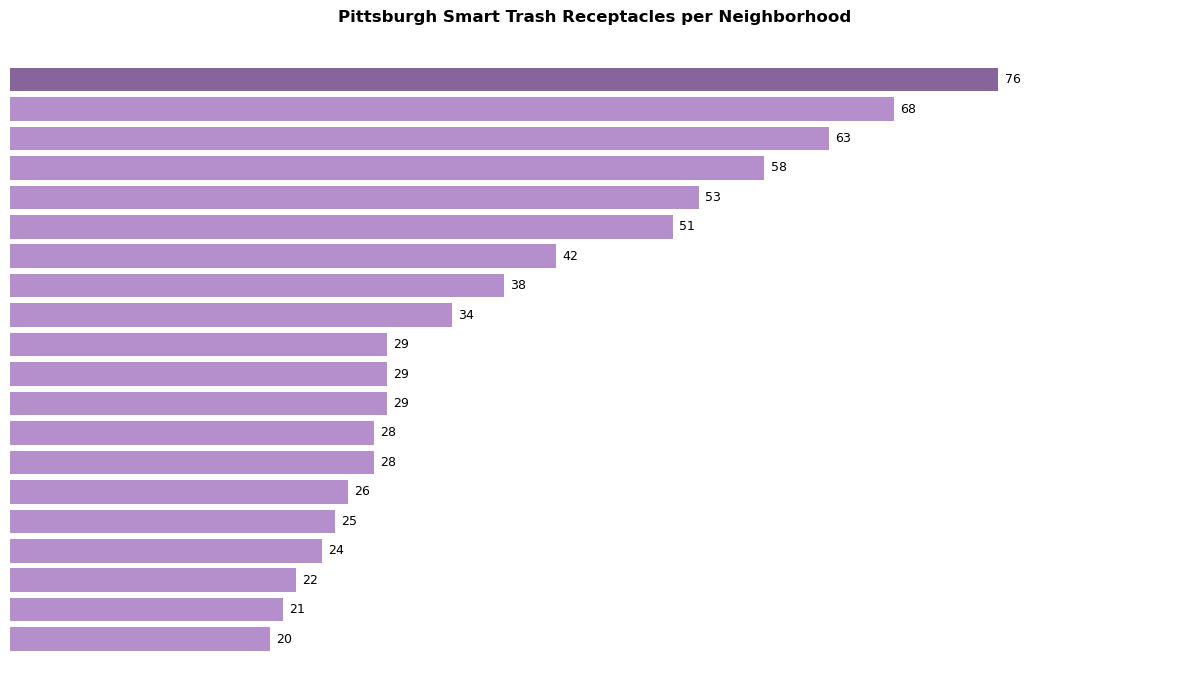

In [17]:
top20 = scores.head(20).copy()
colors = ['#86659C' if n == 'Shadyside' else '#B48FCC' for n in top20['neighborhood']]

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top20['neighborhood'][::-1], top20['smart_trash'][::-1], color=colors[::-1])

for bar in ax.patches:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            int(bar.get_width()), va='center', ha='left', fontsize=9)

ax.set_title('Pittsburgh Smart Trash Receptacles per Neighborhood', fontweight='bold', pad=12)
ax.set_xlim(0, 90)
ax.axis('off')

plt.tight_layout()
plt.savefig('neighborhood_rankings.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# summary

total_neighborhoods = df['neighborhood'].nunique()
shadyside_score = scores[scores['neighborhood'] == 'Shadyside']['smart_trash'].values[0]
second_place = scores.iloc[1]

print(f"Total neighborhoods analyzed:  {total_neighborhoods}")
print(f"\n#1  Shadyside:                  {shadyside_score} receptacles")
print(f"#2  {second_place['neighborhood']}:             {second_place['smart_trash']} receptacles")

Total neighborhoods analyzed:  79

#1  Shadyside:                  76 receptacles
#2  East Liberty:             68 receptacles


## Conclusion


By my metric, Shadyside is objectively the best neighborhood in Pittsburgh. It ranks #1 out of 79 neighborhoods, sits 11% ahead of East Liberty (the runner-up), and scores 5x above the citywide mean. Its investment is consistent year-over-year and reflects the surrounding environment.

### Personal Reflection

Shadyside was one of the first Pittsburgh neighborhoods I visited as a Pitt student, and it makes sense why it's so far ahead of its competitors. There are so many housing developments, stores, including large box stores like Target, and a wealth of restaurants and other smaller businesses. It's accessible to students in Oakland, urban citizens downtown who don't have easy access to grocery stores nearby, and tourists.

As Pittsburgh grows in popularity again, Shaydside is feeling much of the pressure. Consistently adding more smart trash receptacles is one way they're meeting consumer demand, and it is indicative of a larger investment in the community.

![Pittsburgh Map with Neighborhoods](https://i.redd.it/4oh8y7gx0q561.jpg)